In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# ※ Quiz : 경주여행과 전주여행에 대한 최빈단어 시각화와 유사도 분석
- (1) naver open API를 활용하여 블로그에 "경주여행","전주여행"을 각각 500건씩검색하여 백업                 (data/quiz/naver.csv)
    * 백업 파일 내용 : query, no, title, link, description, total, text(title + ' '+description)
- (2) naver.csv에서 total_text를 품사태깅(naver_pos.csv)
    * 파일 내용 : query, no, token, pos
- (3) 명사만 추출(naver_pos_nouns.csv)
    * query, token, pos
- (4) 빈도분석 백업(naver_pos_nouns_count.csv)
    * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도시각화(워드클라우드, Text.plot)
    * 이미지 저장
- (6) 단어간 거리분석(Word2Vac)



In [14]:
# . env가져오기
from dotenv import load_dotenv
import os
load_dotenv()

True

In [15]:
# 네이버 개발자 센터에 있는 소스
import os
import sys
import urllib.request
client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")
encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:200])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 14:20:11 +0900",
	"total":2737699,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"3월의 <b>경주여행<\/b>.",
			"link":"https:\/\/lje77777.tistory.com\/7132",
			"


In [16]:
# 문자 -> dict
import json
from html import unescape # description에 있는 &lt;(특수문자)를 <로 변경
import requests
import pandas as pd
import re # 특수문자 제거

In [17]:
query = "경주 여행"
start = 1
# url =f'https://openapi.naver.com/v1/search/blog.json?query={query}&display=100&start={start}'

url = "https://openapi.naver.com/v1/search/blog.json"
params = {
    'query':query,
    'display':100,
    'start':start
}
headers ={
    "X-Naver-Client-Id":client_id,
    "X-Naver-Client-Secret":client_secret
}

response = requests.get(url,headers=headers, params=params)
# 문자 -> dict
items = json.loads(response.text)['items']
items = response.json()['items']
items[:4]

[{'title': '<b>경주여행</b>) 동궁과월지 첨성대 야경, 연꽃단지, 분황사',
  'link': 'https://green54.tistory.com/1244',
  'description': '<b>경주여행</b> 때 방문했던 곳들을 다시 한번 남겨보려함&gt;&lt; ↓<b>경주여행</b>↓ <b>경주</b>밤에가볼만한곳... 이웃님들 잘 지내셨나요? 지난주 일... blog.naver.com 예전 <b>여행</b>사진을 보니 <b>여행</b>을 떠나고싶어진다.',
  'bloggername': '쏭스라이프의 블로그',
  'bloggerlink': 'https://green54.tistory.com/',
  'postdate': '20250901'},
 {'title': '[경북/<b>경주여행</b>]천문 기상 관측대, 첨성대',
  'link': 'https://kwon-blog.tistory.com/1574',
  'description': '*<b>여행</b>일자: 2016년 9월 7일(목) *<b>여행</b>인원: 친구와 함께 첨성대 경북 <b>경주</b>시 인왕동 839-1 전화: 054-779-8741 첨성대 관람료는 무료! ☞ [경북/<b>경주여행</b>]이야기가 있는 <b>경주여행</b> 첨성대에서 바라본 대릉원 야경... ',
  'bloggername': '여행과인생',
  'bloggerlink': 'https://kwon-blog.tistory.com/',
  'postdate': '20170124'},
 {'title': '<b>경주여행</b>은 원데이 택시투어!',
  'link': 'https://dolphintour1.tistory.com/859',
  'description': '감사합니다:D 구매하러가기 https://smartstore.naver.com/dptour/products/5981873243 <b>경주</b> 핫플레이스 원데이택시투어 : 돌고래<b>여행</b>사-돌핀스토어 <b>경주</b> 핫플레이스 

In [18]:
# title과 description의 <b>없애기, html의 특수문자없애기, 일반특수 없애기
item = items[4]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
title = unescape(title)
title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description)
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
link = item['link']
totaltext = title + ' ' + description
print(totaltext)
print(link)

경북  경주여행  불국사 단아함과 정숙함이 묻어나는 겹벚꽃 왕벚꽃      벚꽃이 다 지고나면 피는 겹벗꽃 봄  여행 을 즐기는 고수라면 서둘러  경주 행 티켓을 예약하자  또다시  경주 가 들썩이고 있다 다  경주 지역 벚꽃은 거의 떨어지고 불국사 쪽이 겹벚꽃으로 유명하다  불국사 입구에    
https://skdywjd25.tistory.com/5973


In [6]:
# re 정규표현식을 이용해서 특수문자 없애기
title = '[여행] ## & ktx 타고 짱 ㅋㅋ ㅠㅠ'
re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)

' 여행       ktx 타고 짱      '

In [19]:
# 네이버 API 정보 및 검색 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

In [20]:
def get_search_item_return(query, start):
    'query, no, title, link, description, total, text(title + ' '+description)'
    import requests
    #import json
    from html import unescape # html 특수문자 제거(ex.&nbsp; 제거)
    import re # 일반 특수문자 제거(__.__제거).
    from dotenv import load_dotenv
    import os
    load_dotenv() #. env파일 읽어오기(환경변수 설정)
    client_id = os.getenv("CLIENT_ID")
    client_secret = os.getenv("CLIENT_SECRET")
    url = "https://openapi.naver.com/v1/search/blog.json"
    params = {
        'query':query,
        'display':100,
        'start':start
    }
    headers ={
        "X-Naver-Client-Id":client_id,
        "X-Naver-Client-Secret":client_secret
    }
    response = requests.get(url,headers=headers, params=params)
    # 문자 -> dict
#     items = json.loads(response.text)['items']
    items = response.json()['items'] # 100개    
    result = [] # items의 title,link,description등을 dict_list로 append
    for i, item in enumerate(items):
        no = (start-1)*100 + i+1 # start가 1일때는 1,2,3...start가 2일때 101,102...
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', title)
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
        description = unescape(description)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)        
        total_text = title + ' ' + description
        #print(query,no,title[5],link,description[:5],total_text[:5])
        result.append({'query':query,
                      'no'    : no,
                      'title' : title,
                      'description' :description,
                      'total_text' : total_text})
    return result



In [21]:
import time
queries = ['경주 여행', '전주 여행']
max_start = 5
result_total = []
for query in queries:
    for start in range(1, max_start+1):
        print(f'{query}읽어오는중...{start}/{max_start}')
        result_total.extend(get_search_item_return(query, start))
        time.sleep(0.5)    

경주 여행읽어오는중...1/5
경주 여행읽어오는중...2/5
경주 여행읽어오는중...3/5
경주 여행읽어오는중...4/5
경주 여행읽어오는중...5/5
전주 여행읽어오는중...1/5
전주 여행읽어오는중...2/5
전주 여행읽어오는중...3/5
전주 여행읽어오는중...4/5
전주 여행읽어오는중...5/5


In [22]:
import pandas as pd
df = pd.DataFrame(result_total)
print(df.shape)
df.loc[498:501]

(1000, 5)


,query,no,title,description,total_text
498,경주 여행,499,가을 경주 여행,경주 도착 오늘은 작년 여름 경주여행 코스였던 서출지와 통일전 그리고 산림 ...,가을 경주 여행 경주 도착 오늘은 작년 여름 경주여행 코스였던 서출지와...
499,경주 여행,500,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행,일상이 고고학 나 혼자 경주 여행 개정증보판 일상이 고고학 시리즈 2 ...,알라딘서재 100자평 일상이 고고학 나 혼자 경주 여행 일상이 고고학 ...
500,전주 여행,1,전주여행 코스 전동성당 고풍스러운 멋이 좋아요,전주여행 코스 전동성당 고풍스러운 멋이 좋아요 당일로 다녀왔던 전주 예전에 ...,전주여행 코스 전동성당 고풍스러운 멋이 좋아요 전주여행 코스 전동성당 고풍스러...
501,전주 여행,2,전주 먹방 여행 남부전통시장 전주 현대옥 콩나물국밥 정성식품 수,2022 12 20 맛집 맛집들 전주여행 전주 먹방투어 한벽집 새우...,전주 먹방 여행 남부전통시장 전주 현대옥 콩나물국밥 정성식품 수 ...


In [23]:
df.to_csv('data/quiz_naver.csv',encoding='cp949',index=False)

# 2. 품사 태깅 백업
- query, no, token, pos ->quiz_naver_pos.csv 백업

In [24]:
df = pd.read_csv('data/quiz_naver.csv',encoding='cp949')
df.head(1)

,query,no,title,description,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사,경주여행 때 방문했던 곳들을 다시 한번 남겨보려함 경주여행 경주 밤...,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...


In [25]:
df_list = df[['query','no','total_text']].values.tolist()
df_list[::500],len(df_list)

([['경주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 '],
  ['전주 여행',
   1,
   ' 전주여행 코스 전동성당 고풍스러운 멋이 좋아요   전주여행 코스 전동성당 고풍스러운 멋이 좋아요  당일로 다녀왔던  전주  예전에 가서 보지 못한 곳까지 잘 둘러보고 왔습니다  이렇게 좋은 봄날에  여행 만 다니면 얼마나 좋을까 라는    철없는 생각을 해    ']],
 1000)

In [26]:
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
postagged_list = [] #품사태깅한 dict list(query, no, token, pos)
stopwords = ['전주','여행','경주']
for i,row in enumerate(df_list):
    if i%250==0:
        print(f'총 1000번중 현재 {i}번째 품사태깅중')
    query = row[0]
    no    = row[1]
    total_text = row[2]
    tagged_list = analyzer.pos(total_text)
    for token,tag in tagged_list:
        if token not in stopwords and len(token)>1 :
            postagged_list.append({'query':query,
                                  'no': no,
                                  'token':token,
                                  'pos': tag})

총 1000번중 현재 0번째 품사태깅중
총 1000번중 현재 250번째 품사태깅중
총 1000번중 현재 500번째 품사태깅중
총 1000번중 현재 750번째 품사태깅중


In [27]:
df_postagged = pd.DataFrame(postagged_list)
df_postagged.to_csv('data/quiz_naver_pos.csv',encoding='cp949',index=False)

# 3. 명사만 추출
- MeCab에서의 명사(NNG, NNP, NP)
- query, token, pos

In [28]:
df_postagged = pd.read_csv('data/quiz_naver_pos.csv',encoding='cp949')
select_pos = ['NNP','NNP','NP']
df_postagged.sample()

,query,no,token,pos
12983,전주 여행,12,맛집,NNG


In [29]:
df_nouns =  df_postagged.loc[df_postagged['pos'].isin(select_pos),['query','token','pos']]
df_nouns.sample()

,query,token,pos
11340,경주 여행,훌리아,NNP


In [30]:
df_nouns.to_csv('data/quiz_naver_pos_nouns.csv',encoding='cp949',index=False)

# 4. 빈도분석
- token, 경주빈도, 전주빈도, 빈도합, 경주비율, 전주비율


In [31]:
df_nouns.groupby(['query'],as_index=False)['pos'].count()

,query,pos
0,경주 여행,1077
1,전주 여행,1586


In [32]:
df_token_grp = df_nouns.groupby(['query','token'],as_index=False).count()
df_token_grp.rename(columns={'pos':'count'},inplace=True)
df_token_grp.sample()

,query,token,count
157,전주 여행,시래,10


In [33]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행',['token','count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행',['token','count']]
df_gj.shape, df_gj.shape

((105, 2), (105, 2))

In [34]:
df_gj.head(2)

,token,count
0,감포,5
1,강동면,10


In [35]:
df_jj.head(2)

,token,count
105,가즈,5
106,강원도,5


In [38]:
# 두 데이터 프래임 병합
import numpy as np
a = pd.DataFrame([{'token':'첨성대','count':10},
                  {'token':'휴가','count':10}])
b = pd.DataFrame([['휴가',20],
                  ['한옥',30]],columns=['token','count'])
display(a)
display(b)
ab = pd.merge(a, b, 
              on='token', # 두 프레임을 병합할 기준 열이름
              how='outer') # inner, left, right, outer
ab.fillna(0, inplace=True)
ab['count_x']=ab['count_x'].astype('int')
ab['count_y']=ab['count_y'].astype(np.int16)
ab

,token,count
0,첨성대,10
1,휴가,10


,token,count
0,휴가,20
1,한옥,30


,token,count_x,count_y
0,첨성대,10,0
1,휴가,10,20
2,한옥,0,30


In [39]:
df_mrg = pd.merge(df_gj, df_jj, on='token', how='outer')
df_mrg = df_mrg.fillna(0)
df_mrg = df_mrg.rename(columns={'count_x':'경주빈도', 'count_y':'전주빈도'})

In [40]:
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype(np.int16)
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int16)
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg = df_mrg.sort_values(by='빈도합', ascending=False)
df_mrg.head()

,token,경주빈도,전주빈도,빈도합
199,한옥마을,0,315,315
57,알라딘,134,50,184
3,경북,92,0,92
162,완산,0,80,80
130,덕진,0,80,80


In [41]:
df_mrg['경주비율'] = round(df_mrg['경주빈도']/df_mrg['빈도합']*100, 1)
df_mrg['전주비율'] = round(df_mrg['전주빈도']/df_mrg['빈도합']*100, 1)
df_mrg.to_csv('data/quiz_naver_nouns_count.csv', index=False, encoding='cp949')

In [42]:
df_mrg.shape

(202, 6)

# 5. 빈도 시각화(워드클라우드, Text)

In [43]:
df_nouns = pd.read_csv('data/quiz_naver_pos_nouns.csv', encoding='cp949')
df_nouns.shape

(2663, 3)

In [44]:
# 경주 명사들만 워드클라우드(data/heart.jpg 이용)
# 전주 명사들만 워드클라우드(data/korea-house-black-fill.png 이용)
gj_noun = df_nouns.loc[df_nouns['query']=='경주 여행','token'].values.tolist()
jj_noun = df_nouns.loc[df_nouns['query']=='전주 여행','token'].tolist() # 시리즈를 리스트로
gj = ' '.join(gj_noun)
jj = ' '.join(jj_noun)
print(gj[:10])
print(jj[:10])

경북 경북 인왕동 
전동성당 전동성당 


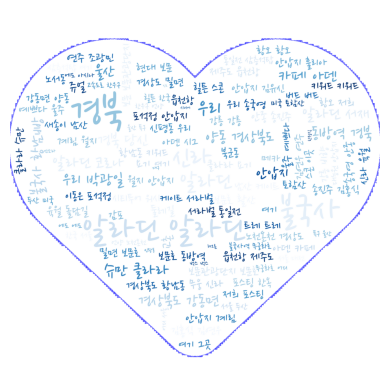

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image
# mask = np.array(Image.open('data/heart.jpg'))
import cv2
mask = cv2.imread('data/heart.jpg')
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(gj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [46]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_경주.jpg')

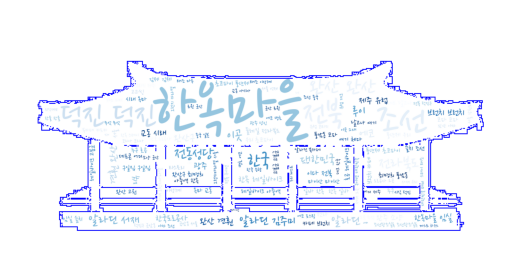

In [47]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/korea-house-black-fill.png'))
# import cv2
# mask = cv2.imread('data/korea-house-black-fill.png')
wordcloud = WordCloud(
    background_color='white',
    colormap="Blues",
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=7,
    font_path = 'data/NanumPenScript-Regular.ttf',
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud.generate(jj)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [48]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/quiz_naver_전주.jpg')

In [49]:
# 경주 명사들 Text plot
# 전주 명사들만 Text plot
print(gj_noun[:5])
print(jj_noun[:5])

['경북', '경북', '인왕동', '경북', '우리']
['전동성당', '전동성당', '누리', '게스트', '하우스']


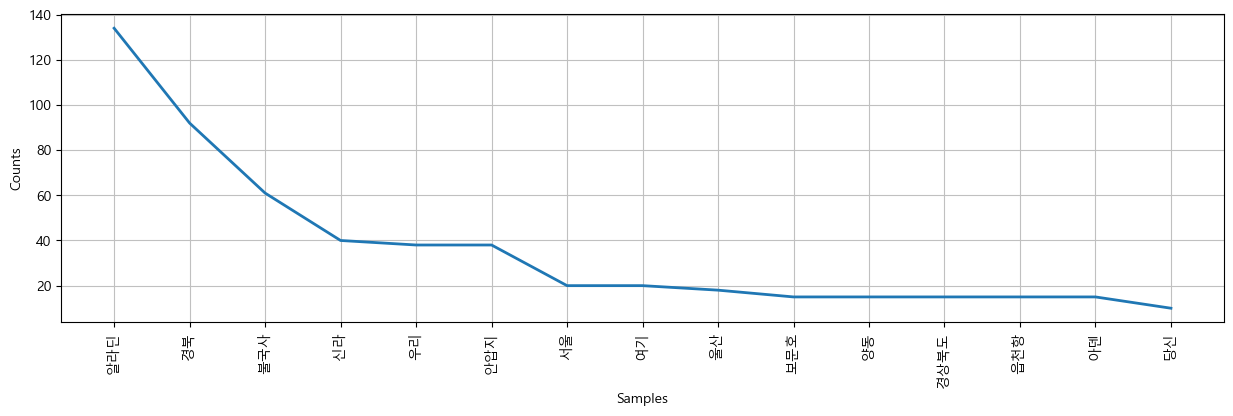

In [50]:
import nltk
import matplotlib.pyplot as plt
gj_text = nltk.Text(gj_noun)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
gj_text.plot(15)
plt.show()

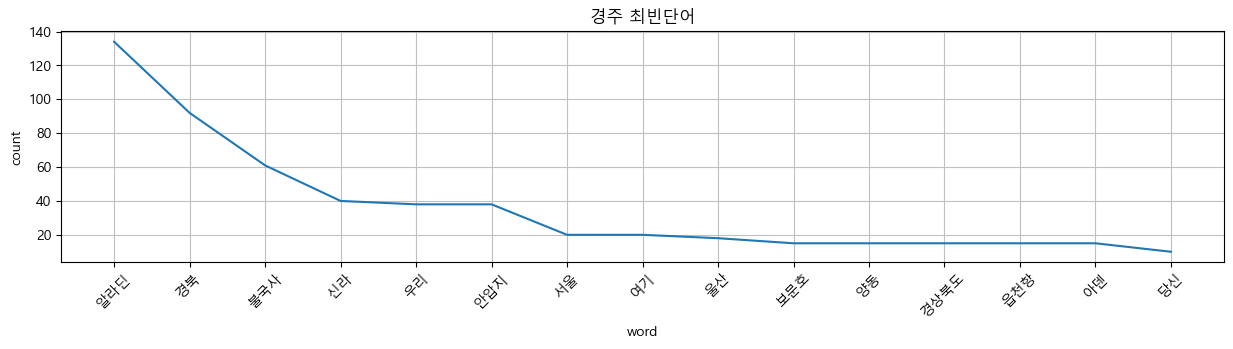

In [51]:
gj_word_counts = gj_text.vocab().most_common(15)
word   = [token for token, count in gj_word_counts]
counts = [count for token, count in gj_word_counts]
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('경주 최빈단어')
plt.grid(True, color='silver') 
plt.show()

In [ ]:
# 경주 명사들만 워드클라우드
# 전주 명사들만 워드클라우드
# 경주 명사들 Text plot
# 전주 명사들만 Text plot


# 6. 워드 임배딩
- Word2Vec

In [52]:
df = pd.read_csv('data/quiz_naver.csv', encoding='cp949')

In [53]:
total_text_list = df['total_text'].values.tolist()
# total_text_list = df['total_text'].to_list() 시리즈를 list로
total_text_list[-2:]

[' 전주여행  카페이르리 메뉴판  전주 한옥마을을 돌아다니가가 수다떨겸 쉴겸 방문하였던 이르리 카페입니다  외관에 비해 내부가     전주  카페 이르리  네이버 지도  카페이르리 전북  전주 시 완산구 은행로 69  교동  http   naver me FqlI7l3r    ',
 '  전주 여행   한옥마을 내  전주  전통 한지원 전라북도  전주 시 일원에서 생산되는 한지  이곳의 한지제조업은 입지와  전주 천의 깨끗한 수질  원재료     전주 지방 근교에 닥나무가 많이 생산되기 때문에 이를 원재료로 한 한지제조업이 성황을 이루고 있다     ']

In [54]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [55]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [word for word, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(word)>1 and
                             word not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

CPU times: total: 1.12 s
Wall time: 1.18 s


In [34]:
df_postagged = pd.read_csv('data/quiz_naver_pos.csv', encoding='cp949')
select_pos = ['NNG', 'NNP', 'NP']

In [56]:
print(total_noun_list[-2:])

[['전주', '카페', '메뉴판', '전주', '한옥마을', '수다', '방문', '카페', '외관', '내부', '전주', '카페', '네이버', '지도', '카페', '전북', '전주', '완산구', '은행', '교동'], ['전주', '한옥마을', '전주', '전통', '지원', '전라북도', '전주', '일원', '생산', '한지', '한지', '제조업', '입지', '전주', '수질', '원재료', '전주', '지방', '근교', '닥나무', '생산', '원재료', '한지', '제조업', '성황']]


In [59]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list,
                window=15,
                min_count=20,
                workers=1,
                sg=1)

In [60]:
model.wv.most_similar('전주')

[('한옥마을', 0.7623836994171143),
 ('전국', 0.7242379188537598),
 ('시민', 0.72090083360672),
 ('막걸리', 0.7115410566329956),
 ('경기전', 0.7091766595840454),
 ('갈비', 0.7053192257881165),
 ('퇴근', 0.6990699172019958),
 ('도시', 0.6953790783882141),
 ('조성', 0.678087055683136),
 ('축제', 0.6664665341377258)]

In [61]:
print(model.wv.index_to_key)
print(len(model.wv))

['전주', '경주', '한옥마을', '일상', '고고학', '맛집', '알라딘', '코스', '공원', '한옥', '마을', '시간', '박물관', '자평', '투어', '지음', '평점', '역사', '불국사', '카페', '고양이', '경북', '황윤', '시리즈', '증보판', '개정', '완산', '덕진', '비빔밥', '황리', '야경', '호텔', '추천', '전북', '첨성대', '조선', '체험', '이야기', '구경', '가을', '시장', '생각', '신라', '사진', '한국', '연꽃', '가족', '대릉원', '방문', '이번', '식당', '필수', '석굴암', '산책', '거리', '문화', '터미널', '벚꽃', '점심', '본향', '서울', '시작', '오늘', '숙소', '추억', '부채', '시외버스', '월지', '후백제', '보문', '도착', '유적지', '안압지', '친구', '위치', '수학', '갈비', '남부', '기대', '현대', '소리', '계획', '풍경', '동궁', '칠봉', '명소', '호수', '하늘', '저녁', '주차장', '주상', '기차', '아이', '국내', '장소', '사람', '경기전', '다음', '버스', '행복', '아침', '전화', '예전', '광장', '시티', '에코', '도서관', '한복', '레시피', '도시', '테마', '스탬프', '황남', '절리', '대표', '분위기', '후기', '교촌', '먹거리', '생태', '전라북도', '완주', '근처', '오후', '공간', '객사', '콩나물국', '전통', '한잔', '날씨', '혼자', '커피', '느낌', '운영', '검색', '군산', '음식', '마중', '풍남문', '대한민국', '아중', '견훤', '케이', '이투', '사고', '이색', '만족', '국밥', '순두부', '마지막', '여름', '해외', '마음', '서재', '김밥', '입장료', '정교', '숨결', '모습', '소개', '남

In [62]:
model.wv.most_similar('경주')

[('느낌', 0.8154036402702332),
 ('이야기', 0.8149418830871582),
 ('신라', 0.7873265147209167),
 ('경북', 0.7766377329826355),
 ('단풍', 0.7634356617927551),
 ('대릉원', 0.7431288361549377),
 ('다음', 0.7296134829521179),
 ('서출지', 0.7223179340362549),
 ('동국', 0.7150174379348755),
 ('택시', 0.7100310325622559)]

In [63]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

입력된 단어와 유사한 단어 10개를 출력합니다.
비빔밥
비빔밥와 유사한 단어:
[('회관', 0.9841421246528625), ('전문점', 0.9639739394187927), ('가족', 0.948195219039917), ('국밥', 0.8528431057929993), ('가게', 0.8339120745658875), ('맛집', 0.8249819874763489), ('체험', 0.8130478858947754), ('아침', 0.8046901226043701), ('오늘', 0.7903816103935242), ('검색', 0.7838664650917053)]
